# OptiTherm Project: Digital Twin and Energy-Efficient Predictive Control (Data-Driven MPC)

### 1. Business Context and Objective

Improving the energy efficiency of commercial buildings is both a financial and environmental priority. Conventional Heating, Ventilation, and Air Conditioning (HVAC) systems typically rely on reactive, rule-based control strategies (e.g., fixed thermostat setpoints), without accounting for the building's complex thermal dynamics or weather forecasts.

**The objective of this project** is to develop a **data-driven Model Predictive Control (MPC)** framework. The proposed approach consists of:

1. Learning the building's thermal and energy dynamics using a deep neural network that serves as a **digital twin**.
2. Integrating this predictive model with an optimization algorithm to compute the optimal control strategy that minimizes energy consumption while maintaining occupants' thermal comfort.

### 2. The Dataset & Reproducibility

To ground this project in a real-world application, we use the **Building Data Genome 2 (BDG2)** dataset. 

> **To run this notebook locally:** You can download the data directly via the Kaggle API. Ensure your Kaggle API credentials are set up on your machine, then run the setup cell below to fetch and extract the data into the `archive/` directory.

::: {.callout-note collapse="true"}
## How to set up Kaggle API credentials

1. Log in to your [Kaggle](https://www.kaggle.com/) account and navigate to **Settings**.
2. Scroll down to the **API** section and generate a new token. Kaggle will provide you with a **Username** and a **Key**.
3. You can authenticate in one of two ways:

**Option A: Directly in Python (Easiest)**
Add a new cell at the top of your notebook with your credentials:

    import os
    os.environ['KAGGLE_USERNAME'] = "your_username"
    os.environ['KAGGLE_KEY'] = "your_api_key"

*Important: If you use this method, remember to delete your key from the cell before pushing the notebook to GitHub!*

**Option B: System Environment Variables (Most Secure)**

* **Windows (Command Prompt):** `setx KAGGLE_USERNAME "your_username"` and `setx KAGGLE_KEY "your_api_key"`
* **Mac/Linux (Terminal):** Add `export KAGGLE_USERNAME="your_username"` and `export KAGGLE_KEY="your_api_key"` to your `~/.bashrc` or `~/.zshrc` file.
:::

---

In [ ]:
import os
import pandas as pd

# Install the kaggle package (uncomment the lines below if running for the first time)
# %pip install -q kaggle
# os.environ['KAGGLE_USERNAME'] = "your_kaggle_user_name"
# os.environ['KAGGLE_KEY'] = "your_kaggle_api_token"

# Download and unzip the dataset directly into the archive folder
os.makedirs("archive", exist_ok=True)
print("Downloading BDG2 dataset from Kaggle...")
!kaggle datasets download -d claytonmiller/buildingdatagenomeproject2 -p archive/ --unzip
print("Download and extraction complete!\n")

# Load the building metadata
df_meta = pd.read_csv("archive/metadata.csv")

print("--- Building Categories ---")
print(df_meta["primaryspaceusage"].value_counts().head(10))

# Filter office buildings
offices = df_meta[df_meta["primaryspaceusage"] == "Office"]

print("\n--- Sample Office Buildings ---")
print(offices[["building_id", "site_id_kaggle", "sqm", "yearbuilt"]].head())

Dataset URL: https://www.kaggle.com/datasets/claytonmiller/buildingdatagenomeproject2
License(s): CC-BY-SA-4.0
buildingdatagenomeproject2.zip: Skipping, found more recently modified local copy (use --force to force download)
Download and extraction complete!

--- Building Categories ---
primaryspaceusage
Education                        617
Office                           307
Entertainment/public assembly    204
Lodging/residential              168
Public services                  166
Other                             29
Healthcare                        29
Parking                           24
Warehouse/storage                 15
Manufacturing/industrial          13
Name: count, dtype: int64

--- Sample Office Buildings ---
               building_id  site_id_kaggle     sqm  yearbuilt
5     Panther_office_Daina             0.0   133.8     1983.0
7   Panther_office_Woodrow             0.0   537.8     1996.0
16    Panther_office_Karla             0.0  2508.4     2010.0
23   Panther_offi

The file archive/buildingdatagenomeproject2.zip is corrupted or not a valid zip file. Please report this issue at https://www.github.com/kaggle/kaggle-cli/issues


### 3. Case Study: The *Panther_office_Graham* Building

After exploring the metadata above, we identified an ideal candidate for developing our digital twin:

* **Building ID:** `Panther_office_Graham` (*Kaggle Site ID: 0.0*)
* **Building type:** Office
* **Floor area:** $7,800\, m^2$
* **Year of construction:** 1974

#### Why this building?

Office buildings exhibit well-defined daily and weekly occupancy patterns, with low occupancy during nights and weekends. In addition, a building constructed in 1974 is likely to have significant thermal inertia and relatively poor insulation compared with modern standards. These characteristics make it an ideal candidate for a predictive AI-based control system, as substantial energy savings can be achieved by anticipating heating and cooling demands while maintaining occupant comfort.

### 4. Methodology and Roadmap

The project is organized into four iterative stages. At each stage, architectural and modeling decisions are driven by insights gained from the data.

#### **Stage 1: Data Engineering and Consolidation**

**Challenge:** The raw data are distributed across large files containing utility meter readings (electricity, chilled water, steam, etc.) and weather station measurements, totaling several gigabytes.

**Objective:** Extract the time series corresponding to the target building and merge them with the associated local weather data to create a clean, lightweight, and analysis-ready dataset.

---

#### **Stage 2: Exploratory Data Analysis (EDA) and Preprocessing**

**Challenge:** Real-world time series are noisy, contain missing values, and exhibit strong seasonal and cyclical patterns.

**Objective:** Explore the relationships between weather variables and energy consumption, handle missing values using appropriate interpolation techniques, and encode temporal cyclicality (e.g., sine/cosine transformations of hour and day) to prepare the data for deep learning models.

---

#### **Stage 3: Learning the Building Dynamics (Deep Learning with PyTorch)**

**Challenge:** A building's thermal state at time *t* depends on its previous states due to thermal inertia. Consequently, conventional regression models are unable to capture these long-term temporal dependencies.

**Objective:** Train a recurrent neural network (LSTM or GRU) on sliding time windows to predict future energy consumption and/or thermal states from weather conditions and control variables.

---

#### **Stage 4: Control Strategy Optimization (Model Predictive Control)**

**Challenge:** Accurate forecasting alone is not sufficient; the ultimate goal is to minimize energy costs while preserving occupant comfort.

**Objective:** Freeze the neural network parameters and use a numerical optimization algorithm (e.g., L-BFGS-B from SciPy) to compute the optimal control sequence that minimizes a cost function combining energy consumption and thermal discomfort penalties.

## Stage 1: Data Engineering and Consolidation

In [45]:
# Parameters for the digital twin
building_id = "Panther_office_Graham"
site_id = "Panther"

print("1. Extracting electricity consumption data...")
df_elec = pd.read_csv("archive/electricity_cleaned.csv", usecols=["timestamp", building_id])
df_elec.rename(columns={building_id: "meter_reading"}, inplace=True)
df_elec["timestamp"] = pd.to_datetime(df_elec["timestamp"])

print(f"2. Extracting weather data (Site: {site_id})...")
df_weather = pd.read_csv("archive/weather.csv")
df_weather_site = df_weather[df_weather["site_id"] == site_id].copy()
df_weather_site.drop(columns=["site_id"], inplace=True)
df_weather_site["timestamp"] = pd.to_datetime(df_weather_site["timestamp"])

print("3. Merging time series...")
df_merged = pd.merge(df_elec, df_weather_site, on="timestamp", how="inner")
df_merged.set_index("timestamp", inplace=True)
df_merged.sort_index(inplace=True)

print(f"\nDataset shape: {df_merged.shape[0]} hourly observations $\\times$ {df_merged.shape[1]} features")
print("\n--- Data Quality Report (Missing Values) ---")
print(df_merged.isna().sum())

1. Extracting electricity consumption data...
2. Extracting weather data (Site: Panther)...
3. Merging time series...

Dataset shape: 17544 hourly observations $\times$ 9 features

--- Data Quality Report (Missing Values) ---
meter_reading      3531
airTemperature        3
cloudCoverage      7542
dewTemperature        3
precipDepth1HR        9
precipDepth6HR    16898
seaLvlPressure      323
windDirection       499
windSpeed             0
dtype: int64


## Stage 2: Exploratory Data Analysis (EDA) and Missing Data Handling

### Data Quality Assessment and Cleaning Strategy

The initial analysis of the merged dataset reveals three distinct patterns of missing values. Each requires a dedicated preprocessing strategy to ensure the reliability of the predictive model.

#### 1. Irrecoverable Features (*To Be Removed*)

The variables **`precipDepth6HR`** (16,898 missing values) and **`cloudCoverage`** (7,542 missing values) exhibit prohibitively high missing rates (approximately 40% to 90% of the dataset). Imputing these variables would effectively generate synthetic weather observations, introducing significant uncertainty into the model. The most robust approach is therefore to remove these features from the dataset.

#### 2. Sparse Missing Values in Exogenous Variables (*To Be Interpolated*)

Meteorological variables such as **`airTemperature`**, **`dewTemperature`**, **`seaLvlPressure`**, and **`windDirection`** contain only a small number of isolated missing values (between 3 and 499 observations). Since these physical quantities evolve smoothly over time, linear time-based interpolation is a reasonable and well-justified preprocessing technique that preserves the underlying temporal dynamics without introducing noticeable distortions.

#### 3. The Critical Variable: Energy Consumption (*`meter_reading`*)

The building's electricity consumption (**`meter_reading`**), which serves as the target variable (ground truth), contains 3,531 missing values (approximately 20% of the dataset). Blindly interpolating the target variable is generally discouraged in supervised learning. If these missing values correspond to an extended sensor outage lasting weeks or months, interpolation would create an artificial signal that does not reflect the building's true thermal behavior. Consequently, the neural network could learn the interpolation artifact instead of the underlying thermal dynamics.

#### Next Step

Before deciding whether to impute or discard these observations, a visual temporal analysis is required to identify the distribution and duration of the electricity meter outages.

1. Cleaning exogenous variables (weather data)...
Missing values after weather data interpolation:
meter_reading     3531
airTemperature       0
dewTemperature       0
precipDepth1HR       0
seaLvlPressure       0
windDirection        0
windSpeed            0
dtype: int64

2. Visual diagnosis of the target variable (meter_reading)...


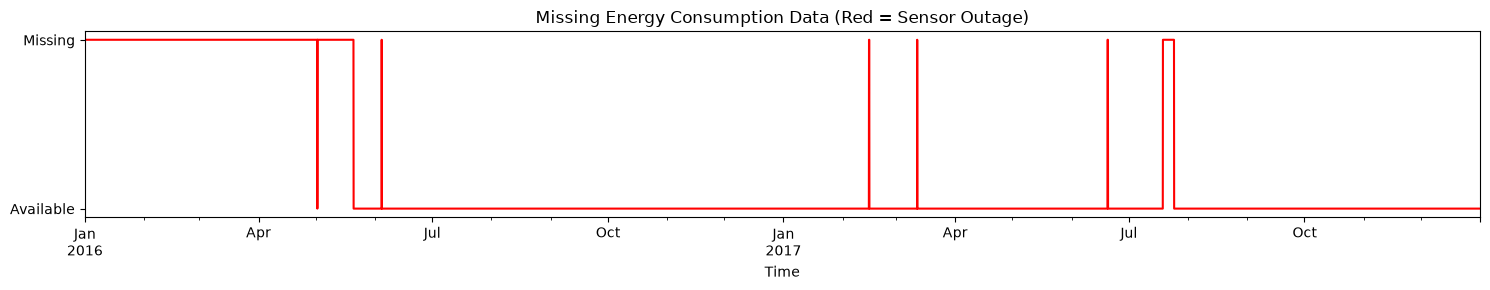

In [46]:
import matplotlib.pyplot as plt

print("1. Cleaning exogenous variables (weather data)...")

# Remove features with excessive missing values
df_merged.drop(columns=["precipDepth6HR", "cloudCoverage"], inplace=True)

# Linear time interpolation to preserve signal continuity
cols_to_interpolate = ["airTemperature", "dewTemperature", "seaLvlPressure", "windDirection", "precipDepth1HR"]
df_merged[cols_to_interpolate] = df_merged[cols_to_interpolate].interpolate(method="linear", limit_direction="both")

print("Missing values after weather data interpolation:")
print(df_merged.isna().sum())

print("\n2. Visual diagnosis of the target variable (meter_reading)...")

# Visualize the temporal distribution of missing meter readings
plt.figure(figsize=(15, 3))
df_merged["meter_reading"].isna().astype(int).plot( color="red", linewidth=1.5)

plt.title("Missing Energy Consumption Data (Red = Sensor Outage)")
plt.yticks([0, 1], ["Available", "Missing"])
plt.xlabel("Time")
plt.tight_layout()
plt.show()

#### Temporal Diagnosis and Target Variable Handling

The temporal analysis reveals a complete absence of energy consumption data from January to the end of May 2016, as well as several shorter missing-data periods, including a prolonged sensor outage of approximately one week during the summer of 2017.

The extended data gap observed at the beginning of the dataset was removed, as the lack of observations over several months prevents any reliable reconstruction of the building's thermal behavior. In contrast, shorter missing periods were handled through linear time interpolation, which preserves the continuity of the energy consumption signal without introducing significant distortions.

Interestingly, the prolonged sensor outage observed during the summer of 2017 was retained and used as a natural temporal boundary between the training and testing datasets. This approach avoids arbitrary data splitting strategies and ensures a realistic evaluation scenario, where the model is trained on past observations and tested on future unseen conditions.

**Methodological justification:**

The thermal dynamics of a building are learned from temporal sequences using recurrent neural networks (RNN/LSTM) with sliding windows. Therefore, preserving the chronological structure of the data is essential. By using the sensor outage as a natural separation point, the model evaluation better reflects a real-world deployment scenario, where future energy consumption must be predicted based solely on historical information.

1. Removing the initial data gap (early 2016)...
2. Target variable interpolation (strict limit)...

--- Final Data Quality Report ---
Dataset size: 13896 hourly observations.
Remaining missing values (corresponding to the summer 2017 outage):
meter_reading     135
airTemperature      0
dewTemperature      0
precipDepth1HR      0
seaLvlPressure      0
windDirection       0
windSpeed           0
dtype: int64

3. Visual diagnosis of the target variable (meter_reading)...


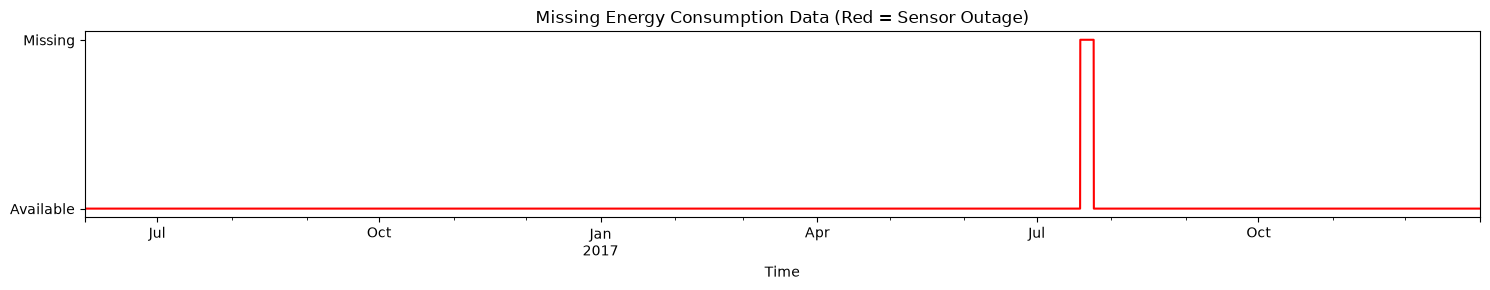

In [47]:
print("1. Removing the initial data gap (early 2016)...")

# Remove the period with insufficient data coverage
df_merged = df_merged.loc["2016-06-01":]

print("2. Target variable interpolation (strict limit)...")

# Interpolate only short missing periods (<= 6 hours).
# The extended summer 2017 outage is intentionally preserved as missing data.
df_merged["meter_reading"] = df_merged["meter_reading"].interpolate(method="linear", limit=6)

print("\n--- Final Data Quality Report ---")
print(f"Dataset size: {df_merged.shape[0]} hourly observations.")
print("Remaining missing values (corresponding to the summer 2017 outage):")
print(df_merged.isna().sum())

print("\n3. Visual diagnosis of the target variable (meter_reading)...")

# Visualize the temporal distribution of remaining missing values
plt.figure(figsize=(15, 3))
df_merged["meter_reading"].isna().astype(int).plot(color="red", linewidth=1.5)

plt.title("Missing Energy Consumption Data (Red = Sensor Outage)")
plt.yticks([0, 1], ["Available", "Missing"])
plt.xlabel("Time")
plt.tight_layout()
plt.show()

#### Visual Validation of the Temporal Splitting Strategy

The final missing-data profile confirms the effectiveness of the preprocessing strategy. The time series now starts consistently in June 2016, and the only remaining discontinuity corresponds to the prolonged sensor outage observed during the summer of 2017.

This temporal gap provides a natural boundary between the training and testing periods, ensuring that the model is evaluated on future unseen data while preserving the chronological structure of the problem. By avoiding artificial data reconstruction in this region, the predictive model is trained and validated on physically consistent energy consumption patterns, preventing potential biases caused by unrealistic interpolated signals.

#### Temporal Feature Engineering

Now that the dataset has been cleaned and validated, the next challenge is to represent time in a way that is meaningful for the neural network.

If the hour of the day is provided as a raw numerical value (from 0 to 23), a machine learning model will incorrectly interpret the temporal distance between 23:00 and 00:00 as large (23 units), even though these two timestamps are only one hour apart in the daily cycle.

To overcome this artificial discontinuity, linear temporal variables are projected onto a continuous periodic space using sine and cosine transformations. This elegant representation maps each temporal coordinate onto the unit circle, preserving the natural proximity between the end and the beginning of each cycle.

***Why use both sine and cosine components?***

Using only one trigonometric function introduces ambiguity due to symmetry. For example, if only the sine component is used, midnight ($\sin(0)=0$) and noon ($\sin(\pi)=0$) would receive the same value, preventing the model from distinguishing between day and night. By combining the cosine component ($X$-axis) and sine component ($Y$-axis), each timestamp is uniquely represented in a two-dimensional periodic space. Consequently, the Euclidean distance between 23:00 and 01:00 is correctly interpreted as small by the neural network.

The following code adds these temporal coordinates to the dataset:

1. Applying cyclical time encoding...
2. Visual validation: Hourly phase space representation...


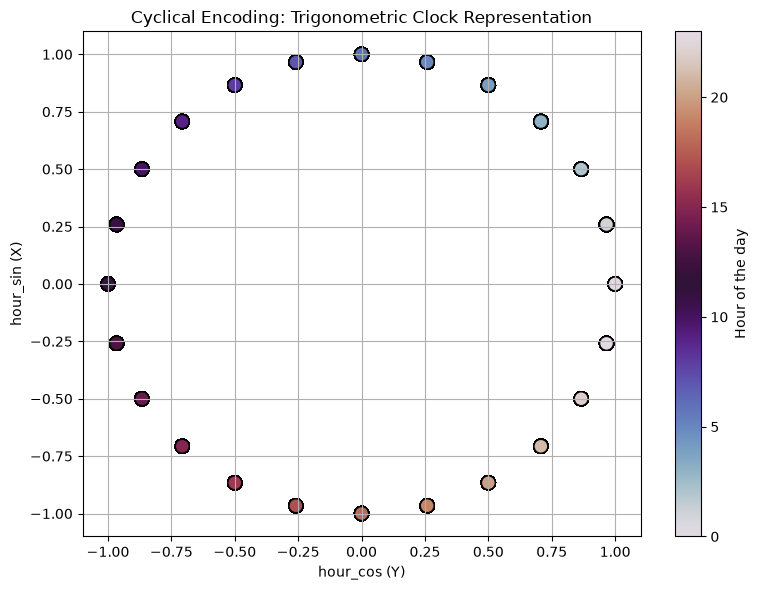

In [48]:
import numpy as np
import matplotlib.pyplot as plt

print("1. Applying cyclical time encoding...")

# Hour of the day (period = 24)
df_merged["hour_sin"] = np.sin(2 * np.pi * df_merged.index.hour / 24.0)
df_merged["hour_cos"] = np.cos(2 * np.pi * df_merged.index.hour / 24.0)

# Day of the week (period = 7)
df_merged["day_sin"] = np.sin(2 * np.pi * df_merged.index.dayofweek / 7.0)
df_merged["day_cos"] = np.cos(2 * np.pi * df_merged.index.dayofweek / 7.0)

# Wind direction (period = 360)
df_merged["wind_sin"] = np.sin(2 * np.pi * df_merged["windDirection"] / 360.0)
df_merged["wind_cos"] = np.cos(2 * np.pi * df_merged["windDirection"] / 360.0)

df_merged.drop(columns=["windDirection"], inplace=True)

print("2. Visual validation: Hourly phase space representation...")

plt.figure(figsize=(8, 6))
plt.scatter( df_merged["hour_cos"], df_merged["hour_sin"], c=df_merged.index.hour, s=100, cmap="twilight", edgecolor="k")

plt.title("Cyclical Encoding: Trigonometric Clock Representation")
plt.xlabel("hour_cos (Y)")
plt.ylabel("hour_sin (X)")
plt.colorbar(label="Hour of the day")
plt.grid(True)
plt.tight_layout()
plt.show()

#### Feature Analysis and Selection: Correlation Study

**Objective:** Identify the exogenous (weather-related) and temporal variables that influence the energy consumption dynamics of the *Panther_office_Graham* building.

**Methodology:** The Pearson correlation coefficient ($r \in [-1,1]$) is used to quantify the strength and direction of the linear relationship between the input features and the target variable (`meter_reading`).

- A value close to $1$ or $-1$ indicates a strong positive or negative linear correlation.
- A value close to $0$ indicates the absence of a significant linear relationship.

This analysis provides valuable insights for feature selection before training the PyTorch model. Variables with limited predictive relevance may be removed to reduce noise and decrease the dimensionality of the input tensors. However, correlation alone does not fully capture the predictive value of a feature, especially in nonlinear time-dependent systems such as building thermal dynamics.

**Code: Correlation Heatmap**

The following visualization uses the `seaborn` library to generate a correlation heatmap, providing an overview of the relationships between the selected features and the energy consumption target.

Calcul de la matrice de corrélation de Pearson...

--- Corrélations avec la consommation électrique ---
                meter_reading
meter_reading        1.000000
airTemperature       0.332953
windSpeed            0.316664
day_sin              0.228865
wind_sin             0.082483
seaLvlPressure       0.034707
precipDepth1HR       0.010033
day_cos             -0.015975
wind_cos            -0.091593
dewTemperature      -0.106052
hour_sin            -0.284356
hour_cos            -0.679665

Génération de la Heatmap globale...


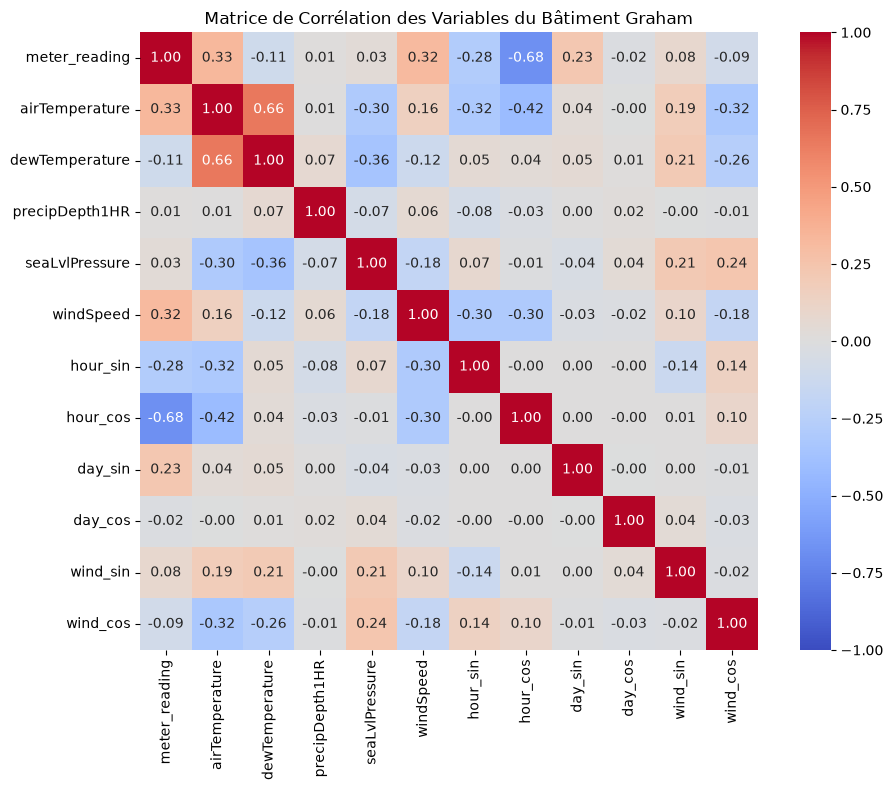

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

print("Calcul de la matrice de corrélation de Pearson...")
# On calcule la corrélation de toutes les variables avec toutes les autres
corr_matrix = df_merged.corr()

# On isole spécifiquement les corrélations par rapport à notre cible
target_corr = corr_matrix[['meter_reading']].sort_values(by='meter_reading', ascending=False)
print("\n--- Corrélations avec la consommation électrique ---")
print(target_corr)

print("\nGénération de la Heatmap globale...")
plt.figure(figsize=(10, 8))
# Le paramètre cmap='coolwarm' permet de bien contraster les corrélations positives (rouge) et négatives (bleu)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Matrice de Corrélation des Variables du Bâtiment Graham")
plt.tight_layout()
plt.show()

#### Pearson Correlation Analysis

The Pearson correlation matrix provides an initial overview of the linear relationships between the input features and the building's electricity consumption.

The results highlight the dominant influence of temporal variables on energy demand. In particular, the daily cyclical components exhibit the strongest correlations, with `hour_cos` reaching a correlation coefficient of approximately -0.68 and `hour_sin` a value of -0.28. This confirms the strong daily periodicity of the building's energy consumption, which is likely driven by occupancy patterns and HVAC operating schedules.

Among the weather-related variables, `airTemperature` and `windSpeed` show the strongest linear relationships with electricity consumption, with correlation coefficients of approximately 0.33 and 0.32, respectively. These results are consistent with the expected influence of outdoor conditions on heating and cooling demand.

Conversely, several variables such as `seaLvlPressure`, `precipDepth1HR`, `wind_sin`, and `wind_cos` exhibit weak instantaneous correlations with the target variable. However, in a thermally dynamic system such as a building, the impact of external conditions is not necessarily immediate. Due to thermal inertia, weather variations may affect energy consumption only after several hours. Consequently, a low instantaneous Pearson correlation does not necessarily indicate that a feature lacks predictive value.

To account for these delayed effects, a lagged Pearson correlation analysis is performed over a 24-hour temporal window. This complementary analysis evaluates whether past values of weakly correlated features contain relevant information about future electricity consumption.

Based on this exploratory analysis, no feature is removed solely based on instantaneous Pearson correlation. Instead, the final feature selection considers a combination of data quality, physical relevance, temporal relationships, and predictive performance during model development.

#### Lagged Correlation Analysis

Since building energy consumption is governed by thermal inertia and delayed responses to external conditions, features with weak instantaneous correlations were further investigated using a lagged Pearson correlation analysis.

The following variables were selected for this additional analysis based on their limited instantaneous correlation with the target variable:

- `wind_sin` and `wind_cos`: cyclic representations of wind direction;
- `seaLvlPressure`: atmospheric pressure;
- `precipDepth1HR`: short-term precipitation measurements;
- `day_cos`: weekly temporal encoding component.

The objective is to determine whether past values of these variables contain predictive information about future electricity consumption over a 24-hour horizon. This analysis helps identify delayed relationships that cannot be captured by a standard Pearson correlation computed at the same timestamp.

--- Lagged Pearson Correlations (24h window) ---

wind_cos
10    0.135799
9     0.132265
11    0.131421
8     0.123380
12    0.120812
dtype: float64

wind_sin
20    0.135305
21    0.134509
19    0.130162
22    0.126679
18    0.123419
dtype: float64

day_cos
24    0.168843
23    0.167962
22    0.166774
21    0.164763
20    0.162125
dtype: float64

seaLvlPressure
9     0.106252
10    0.103067
8     0.100437
11    0.090618
7     0.088409
dtype: float64

precipDepth1HR
9    -0.072556
10   -0.070348
8    -0.069569
11   -0.067131
7    -0.063401
dtype: float64


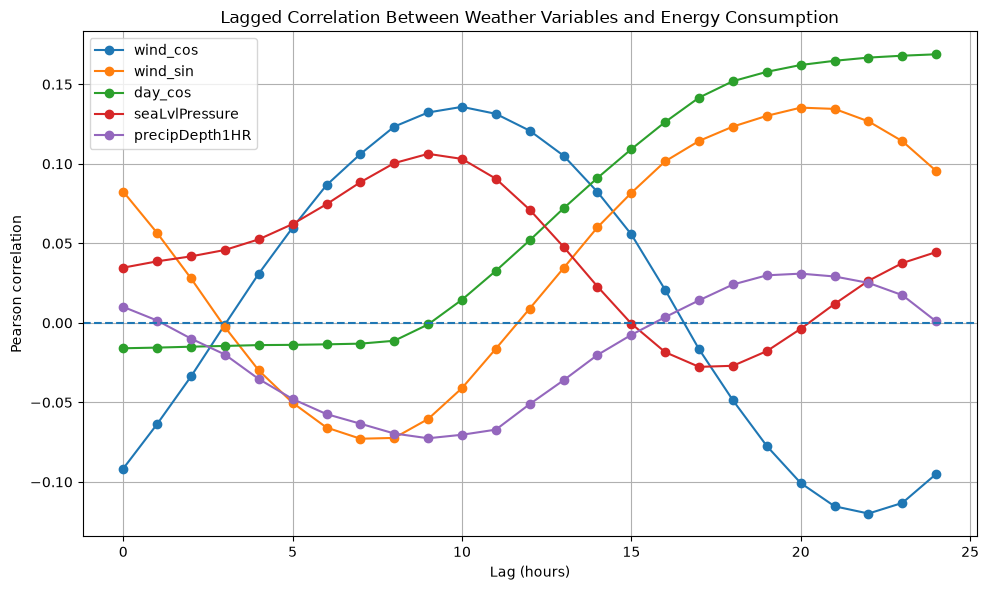

In [50]:
import pandas as pd
import matplotlib.pyplot as plt

def compute_lagged_correlation(df, feature, target="meter_reading", max_lag=24):
    """
    Compute Pearson correlation between a feature and the target
    for different time lags.
    
    Positive lag means that past feature values are correlated
    with future target values.
    """
    correlations = {}

    for lag in range(max_lag + 1):
        shifted_feature = df[feature].shift(lag)
        correlations[lag] = shifted_feature.corr(df[target])

    return pd.Series(correlations)


# Variables to investigate
features_to_test = [
    "wind_cos",
    "wind_sin",
    "day_cos",
    "seaLvlPressure",
    "precipDepth1HR"
]

print("--- Lagged Pearson Correlations (24h window) ---")

plt.figure(figsize=(10, 6))

for feature in features_to_test:
    lag_corr = compute_lagged_correlation(
        df_merged,
        feature,
        target="meter_reading",
        max_lag=24,
    )

    print(f"\n{feature}")
    print(lag_corr.sort_values(key=abs, ascending=False).head(5))

    plt.plot(
        lag_corr.index,
        lag_corr.values,
        marker="o",
        label=feature,
    )

plt.axhline(0, linestyle="--")
plt.xlabel("Lag (hours)")
plt.ylabel("Pearson correlation")
plt.title("Lagged Correlation Between Weather Variables and Energy Consumption")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The results reveal that several variables exhibit weak but non-zero delayed relationships with the target variable. The cyclic wind components (`wind_sin` and `wind_cos`) show maximum correlations around 10 to 21 hours ahead, with coefficients of approximately 0.13. This suggests that wind conditions may have a delayed influence on energy consumption, potentially through their effect on building envelope heat transfer and air infiltration. However, the magnitude of this correlation remains limited.

The weekly temporal encoding variable `day_cos` exhibits a stronger delayed correlation, reaching approximately 0.17 after 20–24 hours. This behavior is consistent with the occupancy patterns of office buildings, where energy demand follows recurring weekly schedules.

The atmospheric pressure variable (`seaLvlPressure`) presents a weak delayed correlation, with a maximum value close to 0.11 around 9 hours. While this indicates a possible relationship with changing weather conditions, its contribution is expected to be limited compared with more direct variables such as outdoor temperature.

Finally, `precipDepth1HR` shows negligible delayed correlations (below 0.08 in absolute value), suggesting that short-term precipitation information provides limited predictive value for the building's electricity consumption.

Based on this analysis, `day_sin` and `day_cos` are retained as essential temporal features, while wind-related variables and atmospheric pressure are kept for further evaluation during model training. The precipitation variable is excluded due to its limited correlation and expected low predictive contribution.

### Sequential Data Preparation and Tensor Construction

**Objective:** Transform the cleaned and engineered time series data into three-dimensional sequences suitable for recurrent neural networks. This representation allows the model to capture temporal dependencies and the thermal inertia of the building.

#### 1. Feature Selection and Input Space Definition

Following the exploratory analysis, feature selection is performed by combining data quality assessment, physical interpretation, and temporal correlation analysis.

Features with insufficient data availability (`cloudCoverage` and `precipDepth6HR`) were removed during the initial preprocessing stage. In addition, `precipDepth1HR` is excluded after the lagged correlation analysis, as it shows limited instantaneous and delayed relationships with electricity consumption, suggesting a negligible predictive contribution.

Conversely, variables with weak instantaneous correlations but potentially meaningful delayed effects, such as wind-related components (`wind_sin` and `wind_cos`), are retained for further evaluation during model training. This approach avoids removing potentially informative features solely based on linear correlation metrics.

The final input space is therefore defined by the combination of physically relevant variables, engineered temporal features, and features supported by the exploratory analysis.

#### 2. Chronological Split and Data Normalization

The prolonged sensor outage observed during the summer of 2017 provides a natural temporal boundary for separating the datasets. The period preceding this interruption (`June 2016 to July 2017`) is used for model training, while the subsequent period (`August 2017 to December 2017`) is reserved for model evaluation.

This chronological split (~75/25) prevents any temporal data leakage and provides a realistic assessment of the model's ability to generalize to unseen seasonal conditions, particularly during the transition toward autumn and winter.

All input variables are normalized using Min-Max scaling. Importantly, the scaling parameters are fitted exclusively on the training set and then applied to the validation/test set to preserve the integrity of the evaluation process.

#### 3. Sliding Window Sequence Generation

Recurrent neural networks require sequential inputs to learn temporal dependencies. The time series is therefore transformed into overlapping sequences of fixed length.

The resulting input tensors have the following dimensions:

\[
(N, L, F)
\]

where:

- $N$ is the number of generated samples;
- $L$ is the sequence length ($L=24$ hours);
- $F$ is the number of input features.

To predict the energy consumption at time $t$, the model receives the previous 24 hours of system information:

\[
[X_{t-24}, X_{t-23}, ..., X_{t-1}]
\]

Any sequence containing missing target values is discarded to ensure that the model is trained only on physically consistent observations.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

print("1. Definition of the model feature space...")

# Features removed after data quality and correlation analysis
cols_to_drop = [
    'precipDepth1HR'
]

df_model = df_merged.drop(columns=cols_to_drop).copy()

print(f"Remaining features: {df_model.columns.tolist()}")

print("\n2. Chronological train/test split using the natural sensor outage...")

# Detect the remaining missing target values corresponding to the sensor outage
nan_indices = df_model[df_model['meter_reading'].isna()].index

if len(nan_indices) > 0:
    gap_start = nan_indices[0]
    gap_end = nan_indices[-1]

    print(f"-> Detected outage period: {gap_start} to {gap_end}")

    # Training set: data before the outage
    df_train = df_model.loc[:gap_start - pd.Timedelta(hours=1)].copy()

    # Test set: data after the outage
    df_test = df_model.loc[gap_end + pd.Timedelta(hours=1):].copy()

else:
    print("-> No outage detected. Using an 80/20 chronological split.")

    split_idx = int(len(df_model) * 0.8)

    df_train = df_model.iloc[:split_idx].copy()
    df_test = df_model.iloc[split_idx:].copy()


print(f"-> Training samples: {len(df_train)} hours")
print(f"-> Testing samples : {len(df_test)} hours")


print("\n3. Min-Max normalization (training data only)...")

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

target_col = 'meter_reading'

# Fit only on training data to avoid data leakage
X_train_scaled = scaler_X.fit_transform(df_train)
y_train_scaled = scaler_y.fit_transform(df_train[[target_col]])

# Apply the same transformation to unseen data
X_test_scaled = scaler_X.transform(df_test)
y_test_scaled = scaler_y.transform(df_test[[target_col]])


print("\n4. Sliding window sequence generation...")


def create_sequences(data_X, data_y, seq_length):
    xs, ys = [], []

    for i in range(len(data_X) - seq_length):

        x_window = data_X[i:i + seq_length]
        y_target = data_y[i + seq_length]

        # Remove sequences containing missing values
        if not (np.isnan(x_window).any() or np.isnan(y_target).any()):
            xs.append(x_window)
            ys.append(y_target)

    return np.array(xs), np.array(ys)


SEQUENCE_LENGTH = 24

X_train_tensor, y_train_tensor = create_sequences(
    X_train_scaled,
    y_train_scaled,
    SEQUENCE_LENGTH
)

X_test_tensor, y_test_tensor = create_sequences(
    X_test_scaled,
    y_test_scaled,
    SEQUENCE_LENGTH
)


print("\n--- Tensor Summary ---")
print(f"Training X: {X_train_tensor.shape}, y: {y_train_tensor.shape}")
print(f"Testing X : {X_test_tensor.shape}, y: {y_test_tensor.shape}")

1. Definition of the model feature space...
Remaining features: ['meter_reading', 'airTemperature', 'dewTemperature', 'seaLvlPressure', 'windSpeed', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'wind_sin', 'wind_cos']

2. Chronological train/test split using the natural sensor outage...
-> Detected outage period: 2017-07-19 01:00:00 to 2017-07-24 15:00:00
-> Training samples: 9913 hours
-> Testing samples : 3848 hours

3. Min-Max normalization (training data only)...

4. Sliding window sequence generation...

--- Tensor Summary ---
Training X: (9889, 24, 11), y: (9889, 1)
Testing X : (3824, 24, 11), y: (3824, 1)


## Stage 4: ThermalLSTM Architecture Definition

With the sequential dataset prepared, the next step is to define the neural network architecture used to learn the building's thermal dynamics.

The objective of this first deep learning model is to construct a data-driven approximation of the relationship between the recent evolution of the building state and its electricity consumption. Because building energy systems exhibit temporal dependencies caused by thermal inertia, a recurrent neural network architecture based on Long Short-Term Memory (LSTM) units is selected.

The proposed model, named **ThermalLSTM**, is designed as a sequence-to-one regression model. It receives a 24-hour historical sequence of building features and outputs a single prediction corresponding to the electricity consumption at the following time step.

The architecture consists of two main components:

1. **LSTM recurrent layers**
   
   The recurrent block extracts temporal patterns from the input sequence and stores relevant information through hidden and cell states. Stacking multiple LSTM layers allows the model to learn increasingly complex temporal representations of the building dynamics.

2. **Fully connected projection layer**
   
   The final hidden representation is mapped to a single scalar value through a linear layer, providing the predicted electricity consumption.

The model parameters are optimized by minimizing the Mean Squared Error (MSE) loss, which is appropriate for this continuous regression problem. The Adam optimizer is selected due to its adaptive learning rate mechanism and its robustness for training deep neural networks.

The following code implements the `ThermalLSTM` architecture and initializes the training configuration.

In [52]:
import torch
import torch.nn as nn
import torch.optim as optim

print("\nDefining the ThermalLSTM architecture...")

class ThermalLSTM(nn.Module):
    r"""__init__(input_size, hidden_size, num_layers=1)

        LSTM-based sequence-to-one model for building energy consumption prediction.
    """

    def __init__(self, input_size, hidden_size, num_layers=1):
        super(ThermalLSTM, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # Recurrent layers
        # Input format: (batch, sequence_length, features)
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)

        # Projection from hidden representation to energy consumption
        self.fc = nn.Linear(in_features=hidden_size, out_features=1)

        # self.fc = nn.Sequential(
        #     nn.Linear(in_features=hidden_size, out_features=hidden_size),
        #     nn.Tanh(),                           # Non-linearity
    
        #     nn.Linear(in_features=hidden_size, out_features=1)
        # )


    def forward(self, x):
        """
        Forward propagation.

        Args:
            x: tensor of shape (batch, sequence_length, features)

        Returns:
            Predicted energy consumption at the next time step.
        """

        # Extract temporal representation
        out, _ = self.lstm(x)

        # Use the hidden state corresponding to the last observation
        last_hidden_state = out[:, -1, :]

        # Map hidden representation to scalar prediction
        prediction = self.fc(last_hidden_state)

        return prediction

    
print("1. Initializing ThermalLSTM model...")

INPUT_SIZE = X_train_tensor.shape[2]
HIDDEN_SIZE = 32
NUM_LAYERS = 1

model = ThermalLSTM(input_size=INPUT_SIZE, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS)
print(model)

print("\n2. Configuring training parameters...")

# Regression loss for continuous energy consumption prediction
criterion = nn.MSELoss()

# Adam optimizer for stable neural network training
learning_rate = 1e-3
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

print(f"-> Learning rate: {learning_rate}")
print("-> Model ready for training.")


Defining the ThermalLSTM architecture...
1. Initializing ThermalLSTM model...
ThermalLSTM(
  (lstm): LSTM(11, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)

2. Configuring training parameters...
-> Learning rate: 0.001
-> Model ready for training.


In [53]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# Device agnostic
device  = "gpu" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Selected device: {device}")

# Data conversion to PyTorch tensors
print("\nConverting NumPy arrays into PyTorch tensors...")
X_train_t = torch.tensor(X_train_tensor, dtype=torch.float32)
y_train_t = torch.tensor(y_train_tensor, dtype=torch.float32)
X_test_t = torch.tensor(X_test_tensor, dtype=torch.float32)
y_test_t = torch.tensor(y_test_tensor, dtype=torch.float32)

print("\nCreating DataLoaders...")
BATCH_SIZE = 64
train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Sending the model to the target device
model.to(device)
print(f"-> Training batches per epoch: {len(train_loader)}")
print(f"-> Model running on: {device}")

Selected device: cpu

Converting NumPy arrays into PyTorch tensors...

Creating DataLoaders...
-> Training batches per epoch: 155
-> Model running on: cpu


## Stage 5: ThermalLSTM Training and Model Optimization

After defining the architecture and preparing the sequential data loaders, the ThermalLSTM model is trained to learn the relationship between historical building states and future electricity consumption.

The training process follows a supervised learning strategy based on gradient descent. For each batch of sequences, the model performs a forward propagation to estimate the energy consumption, the Mean Squared Error (MSE) loss is computed, and the network parameters are updated through backpropagation using the Adam optimizer.

The training procedure is organized into two phases:

1. **Training phase**
   
   The model parameters are updated using the training sequences. The optimizer minimizes the prediction error by iteratively adjusting the LSTM weights.

2. **Evaluation phase**
   
   After each epoch, the model is evaluated on the future unseen dataset separated by the natural sensor outage boundary. This chronological evaluation provides a realistic measure of the model's generalization capability.

The evolution of the training and evaluation losses is stored throughout the optimization process to monitor convergence and detect potential overfitting.

In [ ]:
import torch

print("Configuring the training loop...")

EPOCHS = 200
PRINT_FREQ = 10
train_losses = []
test_losses = []
best_test_loss = float("inf")
best_model_state = None


for epoch in range(EPOCHS):
    ### Training phase
    model.train()
    running_train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        # Reset gradients
        optimizer.zero_grad()

        # Forward pass
        predictions = model(X_batch)

        # Compute loss
        loss = criterion(predictions, y_batch)

        # Backpropagation
        loss.backward()

        # Update model parameters
        optimizer.step()

        running_train_loss += loss.item() * X_batch.size(0)

    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    # Evaluation phase
    model.eval()

    running_test_loss = 0.0
    with torch.inference_mode():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            predictions = model(X_batch)

            loss = criterion(predictions, y_batch)
            running_test_loss += loss.item() * X_batch.size(0)


    epoch_test_loss = running_test_loss / len(test_loader.dataset)
    test_losses.append(epoch_test_loss)

    # Save best model
    if epoch_test_loss < best_test_loss:
        best_test_loss = epoch_test_loss
        best_model_state = model.state_dict()


    if (epoch + 1) % PRINT_FREQ == 0 or epoch == 0:

        print( f"Epoch [{epoch+1}/{EPOCHS}] "
               f"| Train Loss (MSE): {epoch_train_loss:.6f} "
               f"| Test Loss (MSE): {epoch_test_loss:.6f}"
        )

print("\n--- Training completed successfully! ---")

# Restore the best performing model
model.load_state_dict(best_model_state)

print(f"Best test MSE: {best_test_loss:.6f}")

Configuring the training loop...
Epoch [1/200] | Train Loss (MSE): 0.035841 | Test Loss (MSE): 0.027361
Epoch [10/200] | Train Loss (MSE): 0.002577 | Test Loss (MSE): 0.004197
Epoch [20/200] | Train Loss (MSE): 0.001275 | Test Loss (MSE): 0.002554
Epoch [30/200] | Train Loss (MSE): 0.000780 | Test Loss (MSE): 0.001693
Epoch [40/200] | Train Loss (MSE): 0.000650 | Test Loss (MSE): 0.001265
Epoch [50/200] | Train Loss (MSE): 0.000585 | Test Loss (MSE): 0.001228
Epoch [60/200] | Train Loss (MSE): 0.000554 | Test Loss (MSE): 0.001298
Epoch [70/200] | Train Loss (MSE): 0.000534 | Test Loss (MSE): 0.001220
Epoch [80/200] | Train Loss (MSE): 0.000516 | Test Loss (MSE): 0.001382
Epoch [90/200] | Train Loss (MSE): 0.000485 | Test Loss (MSE): 0.001198
Epoch [100/200] | Train Loss (MSE): 0.000480 | Test Loss (MSE): 0.001179
Epoch [110/200] | Train Loss (MSE): 0.000474 | Test Loss (MSE): 0.001047
Epoch [120/200] | Train Loss (MSE): 0.000447 | Test Loss (MSE): 0.001095
Epoch [130/200] | Train Loss 

1. Generating predictions on the test set...
2. Plotting the Actual vs Predicted comparison with Dates...


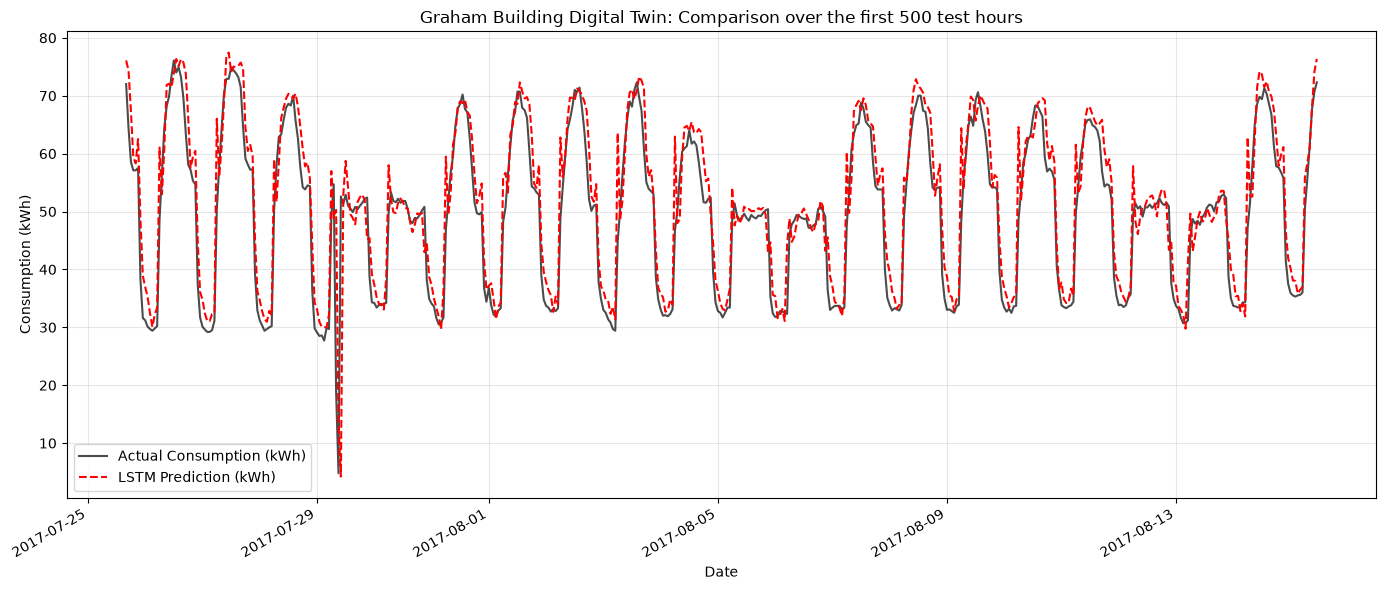

In [64]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

print("1. Generating predictions on the test set...")
model.eval()
predictions_list = []
actuals_list = []

with torch.inference_mode():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds = model(X_batch)

        # Retrieving predictions and actual values on the CPU
        predictions_list.extend(preds.cpu().numpy())
        actuals_list.extend(y_batch.numpy())

# 2. Inverting the normalization to return to kWh
predictions_rescaled = scaler_y.inverse_transform(np.array(predictions_list))
actuals_rescaled = scaler_y.inverse_transform(np.array(actuals_list))

print("2. Plotting the Actual vs Predicted comparison with Dates...")

# Extract the corresponding timestamps for the first 500 predictions
# (Skipping the first SEQUENCE_LENGTH hours used for the first window)
SEQUENCE_LENGTH = 24 
test_dates = df_test.index[SEQUENCE_LENGTH : SEQUENCE_LENGTH + 500]

plt.figure(figsize=(14, 6))
plt.plot(test_dates, actuals_rescaled[:500], label="Actual Consumption (kWh)", color='black', alpha=0.7, linewidth=1.5)
plt.plot(test_dates, predictions_rescaled[:500], label="LSTM Prediction (kWh)", color='red', linestyle='--', linewidth=1.5)

plt.title("Graham Building Digital Twin: Comparison over the first 500 test hours")
plt.xlabel("Date")
plt.ylabel("Consumption (kWh)")
plt.legend()
plt.grid(True, alpha=0.3)

# Automatically format the x-axis dates to look clean and prevent overlapping
#plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gcf().autofmt_xdate()

plt.tight_layout()
plt.show()

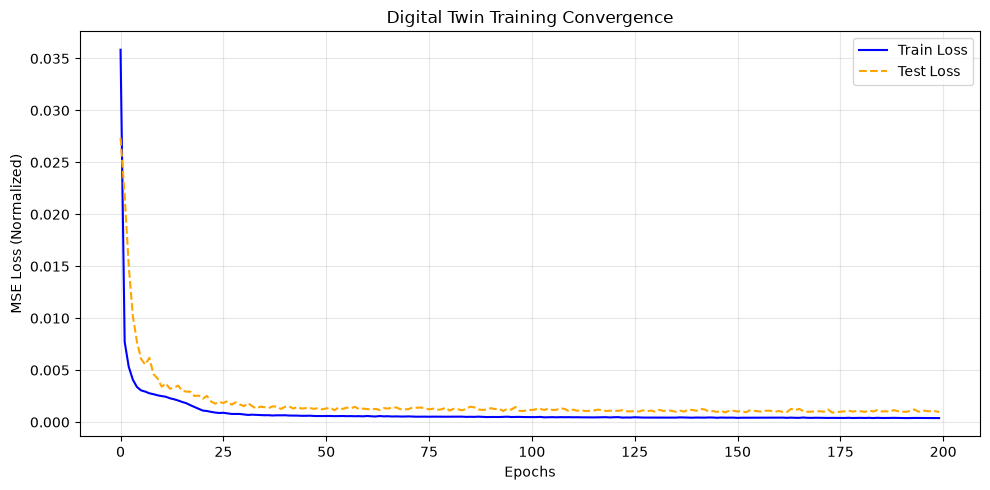

In [56]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss", color='blue')
plt.plot(test_losses, label="Test Loss", color='orange', linestyle='--')
plt.title("Digital Twin Training Convergence")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss (Normalized)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

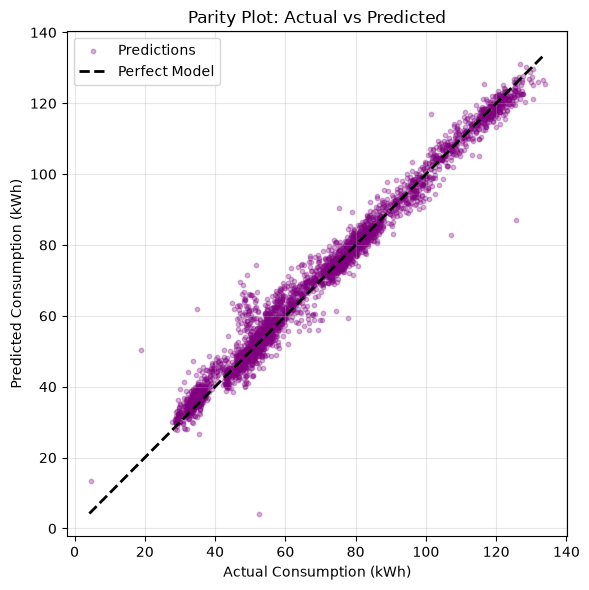

In [65]:
plt.figure(figsize=(6, 6))
plt.scatter(actuals_rescaled, predictions_rescaled, alpha=0.3, color='purple', s=10, label="Predictions")

# Ideal line y = x
min_val = min(actuals_rescaled.min(), predictions_rescaled.min())
max_val = max(actuals_rescaled.max(), predictions_rescaled.max())
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', linewidth=2, label="Perfect Model")

plt.title("Parity Plot: Actual vs Predicted")
plt.xlabel("Actual Consumption (kWh)")
plt.ylabel("Predicted Consumption (kWh)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5. Conclusion and Engineering Insights

The development of the data-driven digital twin for the *Panther_office_Graham* building yielded highly promising results, demonstrating the viability of using deep learning for building energy modeling.

Based on the model's outputs, we can draw the following key conclusions:

* **Accurate Capture of Thermal Dynamics:** The time-series comparison shows that the LSTM network successfully learned the building's operational schedule and thermal inertia. It accurately anticipates the sharp morning ramp-ups in energy consumption as well as the extended drops during nights and weekends.
* **Robust Generalization (No Overfitting):** The training convergence plot demonstrates that both the training and test losses stabilized quickly (within the first 25 epochs). The test loss remained consistently low without diverging, confirming that the chronological split and 24-hour sequence structure prevented data leakage and overfitting.
* **High Reliability Across Load Profiles:** The parity plot reveals a tight clustering of predictions along the ideal model line. The digital twin exhibits minimal bias across the entire consumption spectrum, performing just as reliably during peak load hours (~120 kWh) as it does during baseline operations (~30 kWh).

**Next Steps:**
With a highly accurate and responsive digital twin established, the next logical phase in this project is the implementation of a **Model Predictive Control (MPC)** optimizer. By pairing this LSTM forward-prediction model with an optimization algorithm (such as Sequential Quadratic Programming or a Genetic Algorithm), we can actively compute optimal HVAC setpoints that minimize future energy costs while strictly enforcing occupant comfort constraints.